<center>
  <h1>Aritimética fuzzy interativa aplicada ao método da secante</h1>
  <b>Yasmin B. Shimizu & Vinícius F. Wasques</b>
</center>

<p style="text-align: center;">
 Interatividade Fuzzy · Sistemas Fuzzy · Método da Secante · Zeros de Funções
</p>


<p style="text-align: center;">
  Parte do Projeto de Iniciação Científica <b>Estudo de interatividade e aritmética fuzzy com aplicações em quadrados mínimos fuzzy e problemas inversos</b> (FAPESP n° 2025/26138-6) para o Workshop de Biometria 2026 - Unesp Botucatu.
</p>

<center>
  <img src="https://github.com/yasminbshimizu/IC_Fuzzy_Aritmetica_Interatividade_QuadradosMinimosPI/blob/main/Images/logo_fapesp_ilum_sfundo.png?raw=true" width="1000"/>
    <img src="https://images.even3.com/NJp2CmZJkHb9-Bz5cuxkX-yj9yw=/1100x440/smart/https://static.even3.com/banner/Designsemnome.7fdea48625054e81855d.png" width="600"/>
</center>

## 📝 Introdução 
---

A busca por <b>zeros de funções</b> é um problema amplamente abordado na literatura. Do ponto de vista analítico, a obtenção das raízes pode não ser simples, tornando necessário o uso de <b>métodos númericos</b> para sua aproximação. O <i>método de Newton</i> é um procedimento iterativo para esse problema, baseado na expansão de Taylor, e é dado por [1,3] 

\begin{equation}
    x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}.
\end{equation}


Entretanto, o cálculo de derivadas também pode ser inviável, surgindo alternativas como o <b>método da secante</b>, dado por [1]. 


\begin{equation}
    x_{n+1} = x_n - f(x_n)\;\frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}.
\end{equation}


Ambos os métodos apresentam uma taxa de convergência similar com chutes iniciais $p_0$ e $p_1$ próximos da raíz $p$, e é possível aplicar critérios de parada, como número máximo de iterações e uma tolerância de convergência. 

Quando falamos de <b>funções com ruído</b>, estes métodos podem ser estendidos pela <b>lógica fuzzy</b>, na qual os números são representados por conjuntos associados a uma função de pertinência entre $0$ e $1$ [2]. Dependendo da aritmética utilizada, a incerteza pode ser propagada pelas iterações. Assim, <b>aritméticas interativas</b> são utilizadas para maior <b>controle da incerteza</b> [2].

O objetivo deste trabalho é adaptar o \textbf{método da secante} à <b>lógica fuzzy</b> utilizando <b>aritmética iterativa</b>. Nesse sentido, foram utilizadas soma interativa $J_0$ ($+_0$) [2] e divisão generalizada ($\div_g$) [4]. 

Sejam os números fuzzy $[A]_\alpha	= [a_\alpha^-, a_\alpha^+]$ e $[B]_\alpha	= [b_\alpha^-, b_\alpha^+]$, $\forall\alpha \in [0,1]$. A **soma interativa** $J_0$ ($+_0$) é definida por [2]:

\begin{equation} 
[A+_0 B]_\alpha
=
\Bigg[
 \inf_{\beta \ge \alpha}
\min
\left\{
a^{-}_{\beta}+b^{+}_{\beta}
,
\;
a^{+}_{\beta}+b^{-}_{\beta}
\right\},
\;
 \sup_{\beta \ge \alpha}
\max
\left\{
a^{-}_{\beta}+b^{+}_{\beta},
\;
a^{+}_{\beta}+b^{-}_{\beta}
\right\}
\Bigg]
\end{equation}

A **divisão generalizada** ($\div_g$) é definida por [4]: 

\begin{equation}\label{eq:gdiv} 
    [C]_\alpha=[A]_\alpha\div_g[B]_\alpha\Leftrightarrow \begin{cases}
        (i) & [A]_\alpha=[B]_\alpha[C]_\alpha, \text{ ou}\\
        (ii) & [B]_\alpha=[A]_\alpha[C]_\alpha^{-1}
    \end{cases}.
\end{equation}

Serão exploradas <b>três abordagens</b>, considerando funções crisp com entradas fuzzy ($P_{\mathcal{F}}, f_{\mathbb{R}}$), funções fuzzy com entrada crisp ($P_{\mathbb{R}}, f_{\mathcal{F}}$), e funções fuzzy com entradas fuzzy ($P_{\mathcal{F}}, f_{\mathcal{F}}$). O método foi testado em diferentes tipos de funções.

## 🧮 Metodologia
---

Primeiramente, as bibliotecas utilizadas para implementação computcional e visualização são importadas. Além disso, importamos as funções construídas para realizar as operações fuzzy e o método da secante.

 <div class="alert alert-warning">
  <div style="text-align: center; font-size: 14px"> ⚠️ Para o funcionamento deste notebook, é necessário que o arquivo <a href="https://github.com/yasminbshimizu/IC_Fuzzy_Aritmetica_Interativa/blob/main/Workshop%20de%20Biometria%202026%20-%20Unesp%20Botucatu/fuzzy_msecante.py"><code>fuzzy_msecante.py</code></a> esteja baixado no mesmo diretório em que este sendo executado!! </div>
</div>   

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from fuzzy_msecante import msecante
from fuzzy_msecante import msecante_fuzzy

from fuzzy_msecante import crisp2fuzzy, prod_fuzzy, gdivisao_nbreak, metr_hausdorff
from fuzzy_msecante import soma_interativa_gamma, dif_interativa_gamma, oposto_fuzzy
from fuzzy_msecante import exp_fuzzy, sen_fuzzy, cos_fuzzy

Para incorporar a lógica fuzzy, vamos considerar dois tipos de função: um com coeficientes crisp e um com coeficientes fuzzy. Tanto os coeficientes quanto os pontos iniciais fuzzy serão definidos associando uma incerteza de $\pm 0.5$ aos seus correspondentes crisp. As funções utilizadas nesse trabalho abrangem funções polinomiais, trigonométricas, e exponencial.

In [3]:
# exemplo linear : f = 3*x+1

def f_linear(x):
    return 3*x + 1

def f_lin_xfuzzy(x):
    #f = 3*x+1
    prod = 3*x
    um_fzz = crisp2fuzzy(1)
    f = soma_interativa_gamma(prod, um_fzz)
    return f

def ffuzzy_lin(x):
    #f = 3*x+1
    tres_fzz = np.array([np.linspace(2.5, 3, 1001), np.linspace(3.5, 3, 1001)])
    prod = prod_fuzzy(tres_fzz, x)
    um_fzz = np.array([np.linspace(2.5, 1, 1001), np.linspace(3.5, 1, 1001)])
    f = soma_interativa_gamma(prod, um_fzz)
    return f

In [4]:
# exemplo da wiki: f = (x ** 2) - 612

def f_wiki(x):
    return (x ** 2) - 612

def f_wiki_xfuzzy(x):
    #x ** 2 - 612
    prod = prod_fuzzy(x,x)
    cfuzzy = crisp2fuzzy(612)
    f = dif_interativa_gamma(prod, cfuzzy)
    return f

def ffuzzy_wiki(x):
    #x ** 2 - 612
    prod = prod_fuzzy(x,x)
    cfuzzy = np.array([np.linspace(611.5, 612, 1001), np.linspace(612.5, 612, 1001)])
    f = dif_interativa_gamma(prod, cfuzzy)
    return f

In [5]:
# exemplo do burden: f = math.cos(x) - x

def f_burden(x):
    f = math.cos(x) - x
    return f

def f_burden_xfuzzy(x):
    #math.cos(x) - x
    cos = cos_fuzzy(x)
    f = dif_interativa_gamma(cos,x)
    return f

def ffuzzy_burden(x):
    #math.cos(x) - x
    cos = cos_fuzzy(x)
    f = dif_interativa_gamma(cos,x)
    return f

In [6]:
# ex1 do p-fuzzy mnr: x**2 -4

def f_ex1(x):
    f = x**2 -4
    return f

def f_ex1_xfuzzy(x):
    #f = x**2 -4
    prod = prod_fuzzy(x,x)
    cfuzzy = crisp2fuzzy(-4)
    f = dif_interativa_gamma(prod, cfuzzy)
    return f

def ffuzzy_ex1(x):
    #f = x**2 -4
    prod = prod_fuzzy(x,x)
    cfuzzy = np.array([np.linspace(-4.5, -4, 1001), np.linspace(-3.5, -4, 1001)])
    f = dif_interativa_gamma(prod, cfuzzy)
    return f

In [7]:
# ex2 do p-fuzzy mnr: f = math.sin(x) + math.cos(x)

def f_ex2(x):
    f = math.sin(x) + math.cos(x)
    return f

def f_ex2_xfuzzy(x):
    #f = math.sin(x) + math.cos(x)
    sen = sen_fuzzy(x)
    cos = cos_fuzzy(x)
    f = soma_interativa_gamma(sen, cos)
    return f

def ffuzzy_ex2(x):
    #f = math.sin(x) + math.cos(x)
    sen = sen_fuzzy(x)
    cos = cos_fuzzy(x)
    f = soma_interativa_gamma(sen, cos)
    return f

In [8]:
# exponecial negativa: math.exp(-x) -1

def f_nexp(x):
    f = math.exp(-x) -1
    return f

def f_nexp_xfuzzy(x):
    #f = math.exp(-x) -1
    opx =  oposto_fuzzy(x)
    exp = exp_fuzzy(opx)
    um_fzz = crisp2fuzzy(-1)
    f = dif_interativa_gamma(exp, um_fzz)
    return f

def ffuzzy_nexp(x):
    #f = math.exp(-x) -1
    opx =  oposto_fuzzy(x)
    exp = exp_fuzzy(opx)
    um_fzz = np.array([np.linspace(-1.5, -1, 1001), np.linspace(-0.5, -1, 1001)])
    f = dif_interativa_gamma(exp, um_fzz)
    return f

In [9]:
# exponecial negativa:  math.exp(-x) -1 + math.cos(x)

def f_nexp_cos(x):
    f = math.exp(-x) -1 + math.cos(x)
    return f

def f_nexp_cos_xfuzzy(x):
    #f = math.exp(-x) -1 +cos(x)
    opx =  oposto_fuzzy(x)
    exp = exp_fuzzy(opx)
    um_fzz = crisp2fuzzy(-1)
    eum = dif_interativa_gamma(exp, um_fzz)
    cos = cos_fuzzy(x)
    f = soma_interativa_gamma(eum, cos)
    return f

def ffuzzy_nexp_cos(x):
    #f = math.exp(-x) -1 +cos(x)
    opx =  oposto_fuzzy(x)
    exp = exp_fuzzy(opx)
    um_fzz = np.array([np.linspace(-1.5, -1, 1001), np.linspace(-0.5, -1, 1001)])
    eum = dif_interativa_gamma(exp, um_fzz)
    cos = cos_fuzzy(x)
    f = soma_interativa_gamma(eum, cos)
    return f

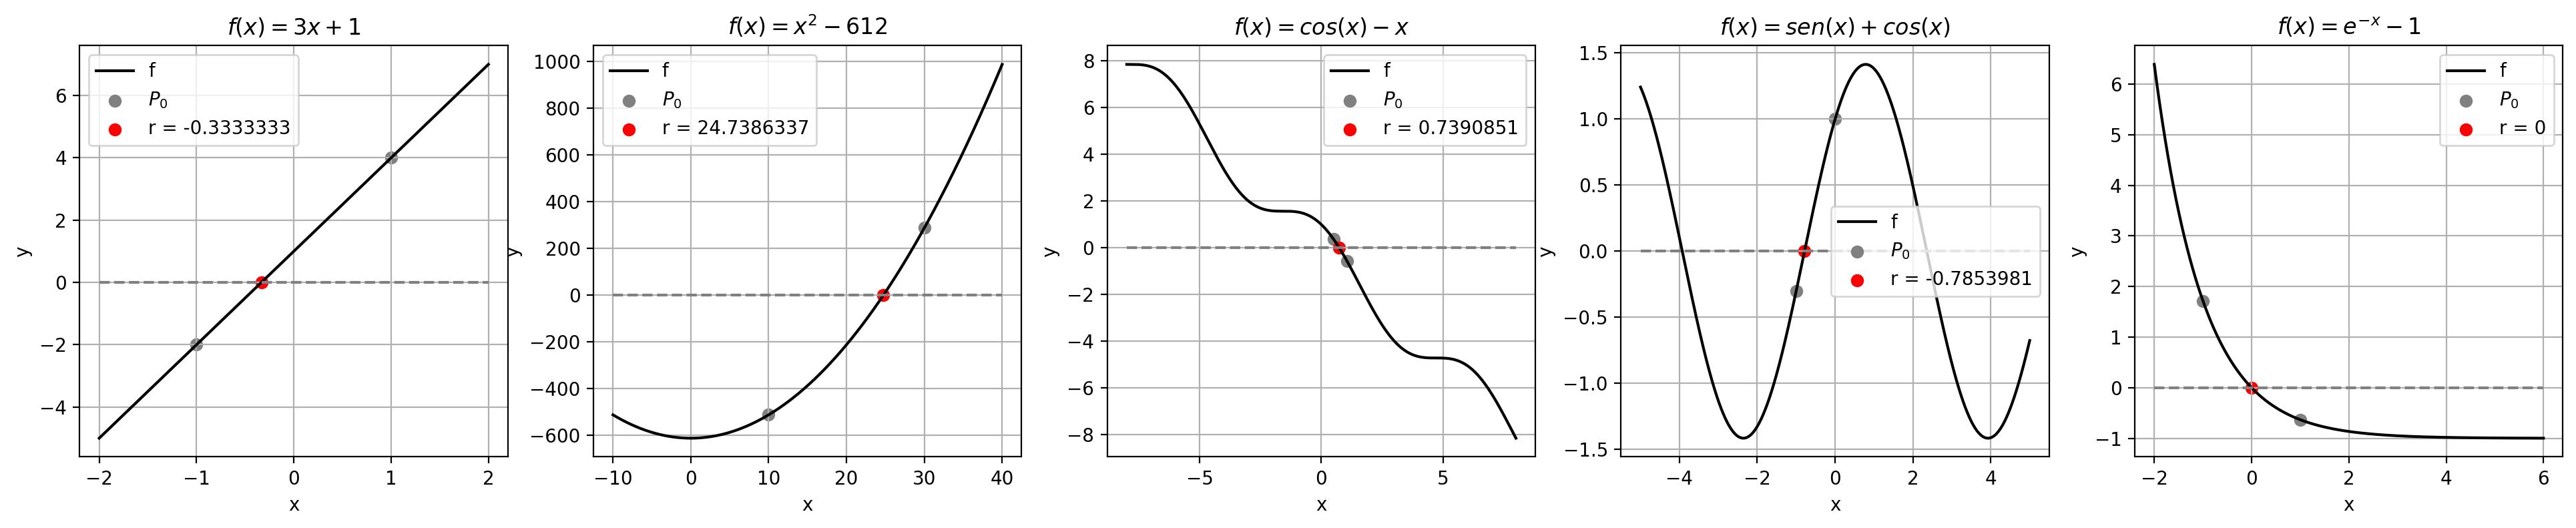

In [10]:
xlin = np.linspace(-2,2, 1001)
xwiki= np.linspace(-10, 40, 1001) 
xburd = np.linspace(-8,8, 1001)
xex2 = np.linspace(-5, 5, 1001) 
xnexp = np.linspace(-2, 6,1001)

flin = [f_linear(x) for x in xlin]
fwiki = [f_wiki(x) for x in xwiki]
fburd = [f_burden(x) for x in xburd]
fex2 = [f_ex2(x) for x in xex2]
fnexp = [f_nexp(x) for x in xnexp]

p0s = [(-1,1), (10,30), (0.5, math.pi/3), (-1, 0), (-1,1)]
f0s = [(f_linear(p0s[0][0]),f_linear(p0s[0][1])), (f_wiki(p0s[1][0]),f_wiki(p0s[1][1])), (f_burden(p0s[2][0]),f_burden(p0s[2][1])), (f_ex2(p0s[3][0]),f_ex2(p0s[3][1])), (f_nexp(p0s[4][0]),f_nexp(p0s[4][1]))]

xs = [xlin, xwiki, xburd, xex2, xnexp]
fs = [flin, fwiki, fburd, fex2, fnexp]

best_funcs = [0,1,2,4,5]

funcoes = [r"$f(x) = 3x+1$", r"$f(x) = x^2 - 612$", r"$f(x) = cos(x) - x$", r"$f(x) = x^2 -4$", r"$f(x) = sen(x) + cos(x)$", r"$f(x) = e^{-x} -1$", r"$f(x) = e^{-x)} -1 + cos(x)$"]
r = [-0.3333333, 24.7386337, 0.7390851, 2, -0.7853981, 0, 0.9236327]

fig, axs = plt.subplots(1,5, dpi= 200, figsize=(24,4))

for i in range(len(best_funcs)):
    f = best_funcs[i]
    
    axs[i].set_title(funcoes[f])
    
    axs[i].plot(xs[i], fs[i], color= "black", label = "f")
    
    axs[i].scatter(p0s[i], f0s[i], color = "grey", label = r"$P_0$")
    axs[i].hlines(0, min(xs[i]), max(xs[i]), color="grey", linestyle = "--")
    axs[i].scatter([r[f]], [0], color= "red", label = f"r = {r[f]}")
    
    axs[i].set_xlabel("x")
    axs[i].set_ylabel("y")
    axs[i].legend()
    axs[i].grid()
plt.show()

Tendo definido as funções, podemos aplicar o método. Salvaremos todos os resultados numa mesma matriz, separando as raízes e a diferença dos pontos a iterações consecutivas.

In [11]:
# função (7) por abordagem (4)
raizes = np.zeros((7,4), dtype=object)
erros = np.zeros((7,4), dtype=object)

### Abordagem 0: Crisp ($P_\mathbb{R}, f_\mathbb{R}$)

In [12]:
# exemplo linear : f = 3*x+1

raizes[0][0], erros[0][0] = msecante(f_linear, -1, 1)

O método convergiu na iteração 1.


In [13]:
# exemplo da wiki: f = (x ** 2) - 612

raizes[1][0], erros[1][0] = msecante(f_wiki, 10, 30)

O método convergiu na iteração 5.


In [14]:
# exemplo do burden: f = math.cos(x) - x

raizes[2][0], erros[2][0] = msecante(f_burden, 0.5, math.pi/3)#, eps = 1e-10)

O método convergiu na iteração 4.


In [15]:
# ex1 do p-fuzzy mnr: x**2 -4

raizes[3][0], erros[3][0] = msecante(f_ex1, 1, 3)#, eps = 0.0001)

# r2,e2 = msecante(f_ex1, -3, -1, eps = 0.0001)

# raizes[3][0] = [r1, r2]
# erros[3][0] = [e1, e2]

O método convergiu na iteração 5.


In [16]:
# ex2 do p-fuzzy mnr: f = math.sin(x) + math.cos(x)

raizes[4][0], erros[4][0] = msecante(f_ex2, -1, 0)#, eps = 0.0001)

O método convergiu na iteração 3.


In [17]:
# exponecial negativa: math.exp(-x) -1

raizes[5][0], erros[5][0] = msecante(f_nexp, -1,1)

O método convergiu na iteração 7.


In [18]:
# exponecial negativa:  math.exp(-x) -1 + math.cos(x)

raizes[6][0], erros[6][0] = msecante(f_nexp_cos, 1,2)

O método convergiu na iteração 3.


### Abordagem  1: $x$  fuzzy  ($P_\mathcal{f}, f_\mathbb{R}$) 

In [19]:
# ex linear: f = 3*x+1

p0 = np.array([np.linspace(-1.5, -1, 1001), np.linspace(-0.5, -1, 1001)])
p1 = np.array([np.linspace(.5, 1, 1001), np.linspace(1.5, 1, 1001)])

raizes[0][1], erros[0][1] = msecante_fuzzy(f_lin_xfuzzy, p0, p1)

O método convergiu na iteração 1.


In [20]:
# exemplo da wiki: x ** 2 - 612

p0 = np.array([np.linspace(9.5, 10, 1001), np.linspace(10.5, 10, 1001)])
p1 = np.array([np.linspace(29.5, 30, 1001), np.linspace(31.5, 30, 1001)])

raizes[1][1], erros[1][1] = msecante_fuzzy(f_wiki_xfuzzy, p0, p1)

O método convergiu na iteração 5.


In [21]:
# exemplo do burden: math.cos(x) - x


p0 = np.array([np.linspace(0, 0.5, 1001), np.linspace(1, 0.5, 1001)])
p1 = np.array([np.linspace(math.pi/3 -0.5, math.pi/3, 1001), np.linspace(math.pi/3 +0.5, math.pi/3, 1001)])

raizes[2][1], erros[2][1] = msecante_fuzzy(f_burden_xfuzzy, p0, p1)#, eps=1e-5)

O alpha-nível de iteração 0, com numerador [-0.014885219447, 0.022766307308] e denominador [-0.053346396952, 0.051155654326], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 2.


In [22]:
# ex1 do p-fuzzy mnr: f = x**2 -4


p01 = np.array([np.linspace(0.5, 1, 1001), np.linspace(1.5, 1, 1001)])
p11 = np.array([np.linspace(2.5, 3, 1001), np.linspace(3.5, 3, 1001)])

raizes[3][1], erros[3][1] = msecante_fuzzy(f_ex1_xfuzzy, p01, p11)

# p02 = np.array([np.linspace(-1.5, 1, 1001), np.linspace(-0.5, 1, 1001)])
# p12 = np.array([np.linspace(-3.5, 3, 1001), np.linspace(-2.5, 3, 1001)])

# r2, e1 = msecante_fuzzy(ffuzzy_ex1_xfuzzy, p02, p12, eps=1e-5)

# raizes[3][1] = [r1,r2]
# erros[3][1] = [e1,e2]

O alpha-nível de iteração 0, com numerador [20.468042263309, 31.385850188905] e denominador [-0.857928290691, 0.924598744888], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 3.


In [23]:
# ex2 do p-fuzzy mnr: f = math.sin(x) + math.cos(x)

p0 = np.array([np.linspace(-1.5, -1, 1001), np.linspace(-0.5, -1, 1001)])
p1 = np.array([np.linspace(-0.5, 0, 1001), np.linspace(0.5, 0, 1001)])

raizes[4][1], erros[4][1] = msecante_fuzzy(f_ex2_xfuzzy, p0, p1)


O alpha-nível de iteração 0, com numerador [-0.000120357729, 1.7346751e-05] e denominador [-0.012752978736, 0.002823070816], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 3.


In [24]:
# exponecial negativa: f = math.exp(-x) -1

p0 = np.array([np.linspace(-1.5, -1, 1001), np.linspace(-0.5, -1, 1001)])
p1 = np.array([np.linspace(0.5, 1, 1001), np.linspace(1.5, 1, 1001)])

raizes[5][1], erros[5][1] = msecante_fuzzy(f_nexp_xfuzzy, p0, p1)

O alpha-nível de iteração 0, com numerador [25654.5916553, 513630.0495941] e denominador [0.0, 0.0], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 4.


In [25]:
# exponecial negativa: f = math.exp(-x) -1 +cos(x)

p0 = np.array([np.linspace(0.5, 1, 1001), np.linspace(1.5, 1, 1001)])
p1 = np.array([np.linspace(1.5, 2, 1001), np.linspace(2.5, 2, 1001)])

raizes[6][1], erros[6][1] = msecante_fuzzy(f_nexp_cos_xfuzzy, p0,p1)

O alpha-nível de iteração 0, com numerador [0.008672568617, 0.035878986979] e denominador [-0.001044537269, 0.049065753726], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 4.


### Abordagem 2: $f$ fuzzy  ($P_\mathbb{R}, f_\mathcal{F}$) 

In [26]:
# ex linear: f = 3*x+1

raizes[0][2], erros[0][2] = msecante_fuzzy(ffuzzy_lin, -1, 1)

O alpha-nível de iteração 0, com numerador [-0.170940175214, 0.036817881131] e denominador [-0.35897435, 0.0], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 2.


In [27]:
# exemplo da wiki: x ** 2 - 612

raizes[1][2], erros[1][2] = msecante_fuzzy(ffuzzy_wiki, 10, 30)

O alpha-nível de iteração 0, com numerador [-1.23788e-05, 1.2373063e-05] e denominador [-0.015210252417, 0.018274744561], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 5.


In [28]:
# exemplo do burden: math.cos(x) - x

raizes[2][2], erros[2][2] = msecante_fuzzy(ffuzzy_burden, 0.5, math.pi/3)

O método convergiu na iteração 4.


In [29]:
# ex1 do p-fuzzy mnr: f = x**2 -4

raizes[3][2], erros[3][2] = msecante_fuzzy(ffuzzy_ex1, 1, 3)

# r2, erros = msecante_fuzzy(ffuzzy_ex1, -1, -3)

# raizes[3][2] = [r1, r2]
# erros[3][2] = [e1, e2]

O alpha-nível de iteração 0, com numerador [-99.617727384241, -26.615187558371] e denominador [-7.087858149918, 6.187888978167], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 30.


In [30]:
# ex2 do p-fuzzy mnr: f = math.sin(x) + math.cos(x)

raizes[4][2], erros[4][2] = msecante_fuzzy(ffuzzy_ex2, -1, 0)

O método convergiu na iteração 3.


In [31]:
# exponecial negativa: f = math.exp(-x) -1

raizes[5][2], erros[5][2] = msecante_fuzzy(ffuzzy_nexp, -1, 1)

O alpha-nível de iteração 0, com numerador [8444.3008148, 624392.0706460499] e denominador [-0.0, 0.0], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 4.


In [32]:
# exponecial negativa: f = math.exp(-x) -1 +cos(x)

raizes[6][2], erros[6][2] = msecante_fuzzy(ffuzzy_nexp_cos, 1,2)

O alpha-nível de iteração 0, com numerador [-0.277294804902, 0.430174750096] e denominador [-0.050626780154, 0.220812044399], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 3.


### Abordagem 3: fuzzy  ($P_\mathcal{f}, f_\mathcal{f}$) 

In [33]:
# ex linear: f = 3*x+1

p0 = np.array([np.linspace(-1.5, -1, 1001), np.linspace(-0.5, -1, 1001)])
p1 = np.array([np.linspace(.5, 1, 1001), np.linspace(1.5, 1, 1001)])

raizes[0][3], erros[0][3] = msecante_fuzzy(ffuzzy_lin, p0, p1)

O método convergiu na iteração 1.


In [34]:
# exemplo da wiki: x ** 2 - 612

p0 = np.array([np.linspace(9.5, 10, 1001), np.linspace(10.5, 10, 1001)])
p1 = np.array([np.linspace(29.5, 30, 1001), np.linspace(31.5, 30, 1001)])

raizes[1][3], erros[1][3]  = msecante_fuzzy(ffuzzy_wiki, p0, p1)

O alpha-nível de iteração 0, com numerador [-0.000841952894, 0.000842495889] e denominador [-0.278364300451, 0.288710106868], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 5.


In [35]:
# exemplo do burden: math.cos(x) - x

p0 = np.array([np.linspace(0, 0.5, 1001), np.linspace(1, 0.5, 1001)])
p1 = np.array([np.linspace(math.pi/3 -0.5, math.pi/3, 1001), np.linspace(math.pi/3 +0.5, math.pi/3, 1001)])

raizes[2][3], erros[2][3]  = msecante_fuzzy(ffuzzy_burden, p0, p1)#, eps=1e-5)

O alpha-nível de iteração 0, com numerador [-0.014885219447, 0.022766307308] e denominador [-0.053346396952, 0.051155654326], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 2.


In [36]:
# ex1 do p-fuzzy mnr: f = x**2 -4

p01 = np.array([np.linspace(0.5, 1, 1001), np.linspace(1.5, 1, 1001)])
p11 = np.array([np.linspace(2.5, 3, 1001), np.linspace(3.5, 3, 1001)])

raizes[3][3], erros[2][3] = msecante_fuzzy(ffuzzy_ex1, p01, p11)

# p02 = np.array([np.linspace(-1.5, 1, 1001), np.linspace(-0.5, 1, 1001)])
# p12 = np.array([np.linspace(-3.5, 3, 1001), np.linspace(-2.5, 3, 1001)])

# r2, e2 = msecante_fuzzy(ffuzzy_ex1, p02, p12, eps=1e-5)


# raizes[3][3] = [r1,r2]
# erros[3][3] = [e1,e2]

O alpha-nível de iteração 0, com numerador [25.055080298937, 28.724873610912] e denominador [-0.32184790553, 0.286499814424], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 3.


In [37]:
# ex2 do p-fuzzy mnr: f = math.sin(x) + math.cos(x)

p0 = np.array([np.linspace(-1.5, -1, 1001), np.linspace(-0.5, -1, 1001)])
p1 = np.array([np.linspace(-.5, 0, 1001), np.linspace(.5, 0, 1001)])

raizes[4][3], erros[4][3] = msecante_fuzzy(ffuzzy_ex2, p0, p1)

O alpha-nível de iteração 0, com numerador [-0.000120357729, 1.7346751e-05] e denominador [-0.012752978736, 0.002823070816], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 3.


In [38]:
# exponecial negativa: f = math.exp(-x) -1

p0 = np.array([np.linspace(-1.5, -1, 1001), np.linspace(-0.5, -1, 1001)])
p1 = np.array([np.linspace(0.5, 1, 1001), np.linspace(1.5, 1, 1001)])

raizes[5][3], erros[5][3] = msecante_fuzzy(ffuzzy_nexp, p0, p1)

O alpha-nível de iteração 0, com numerador [11581.91966835, 110008.88637869999] e denominador [0.0, 0.0], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 4.


In [39]:
# exponecial negativa: f = math.exp(-x) -1 +cos(x)

p0 = np.array([np.linspace(0.5, 1, 1001), np.linspace(1.5, 1, 1001)])
p1 = np.array([np.linspace(1.5, 2, 1001), np.linspace(2.5, 2, 1001)])

raizes[6][3], erros[6][3] = msecante_fuzzy(ffuzzy_nexp_cos, p0,p1)

O alpha-nível de iteração 0, com numerador [-0.18571323427, 0.297665780215] e denominador [-0.395216108929, 0.00507090227], não se encaixa em nenhum caso!
O método apresentou erro de divisão por zero na iteração 2.


## 📈 Resultados
---

Os resultados serão analisados em sua forma gráfica, tornando a interpretação mais intuitiva.

In [40]:
metodo = [r"$P_{\mathbb{R}}$, $f_{\mathbb{R}}$",r"$P_{\mathcal{F}}$, $f_{\mathbb{R}}$", r"$P_{\mathbb{R}}$, $f_{\mathcal{F}}$", r"$P_{\mathcal{F}}$, $f_{\mathcal{F}}$"]
cor = ["black", "purple", "darkblue", "deeppink"]
alphas = np.linspace(0,1,1001)

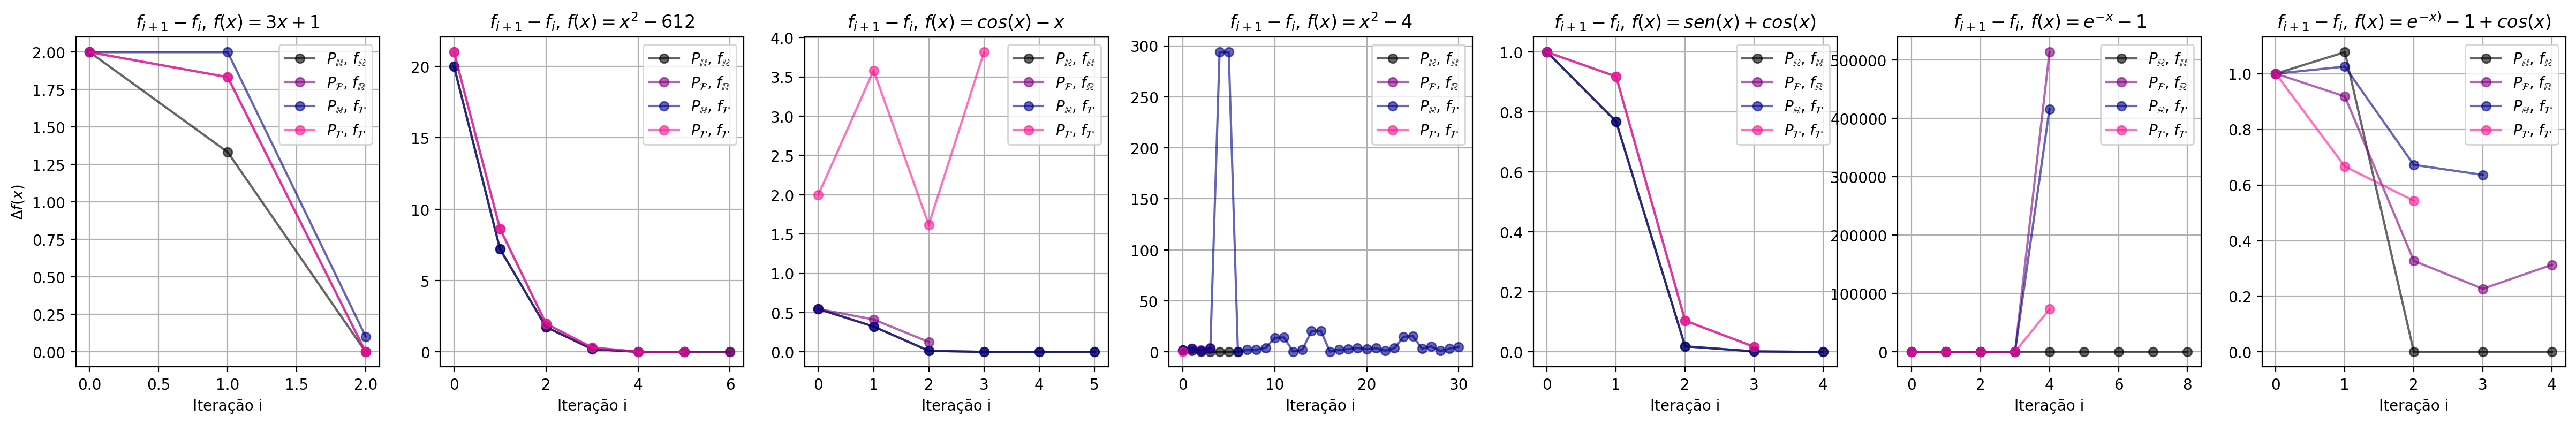

In [41]:
# ERROS
fig, ax = plt.subplots(1,7, dpi= 200, figsize=(30,4))

for i in range(7):
    for j in range(4):
        if isinstance(erros[i][j], (int, float)):
            erros[i][j] = [erros[i][j]]
            
        ax[i].plot(range(len(erros[i][j])), erros[i][j], marker = "o", alpha = 0.6, color = cor[j], label = metodo[j])

    ax[i].set_title(r"$f_{i+1} - f_{i}$, "+funcoes[i])
    
    ax[i].set_xlabel("Iteração i")
    ax[i].legend()
    ax[i].grid()
    
ax[0].set_ylabel(r"$\Delta f(x)$")
    
plt.show()

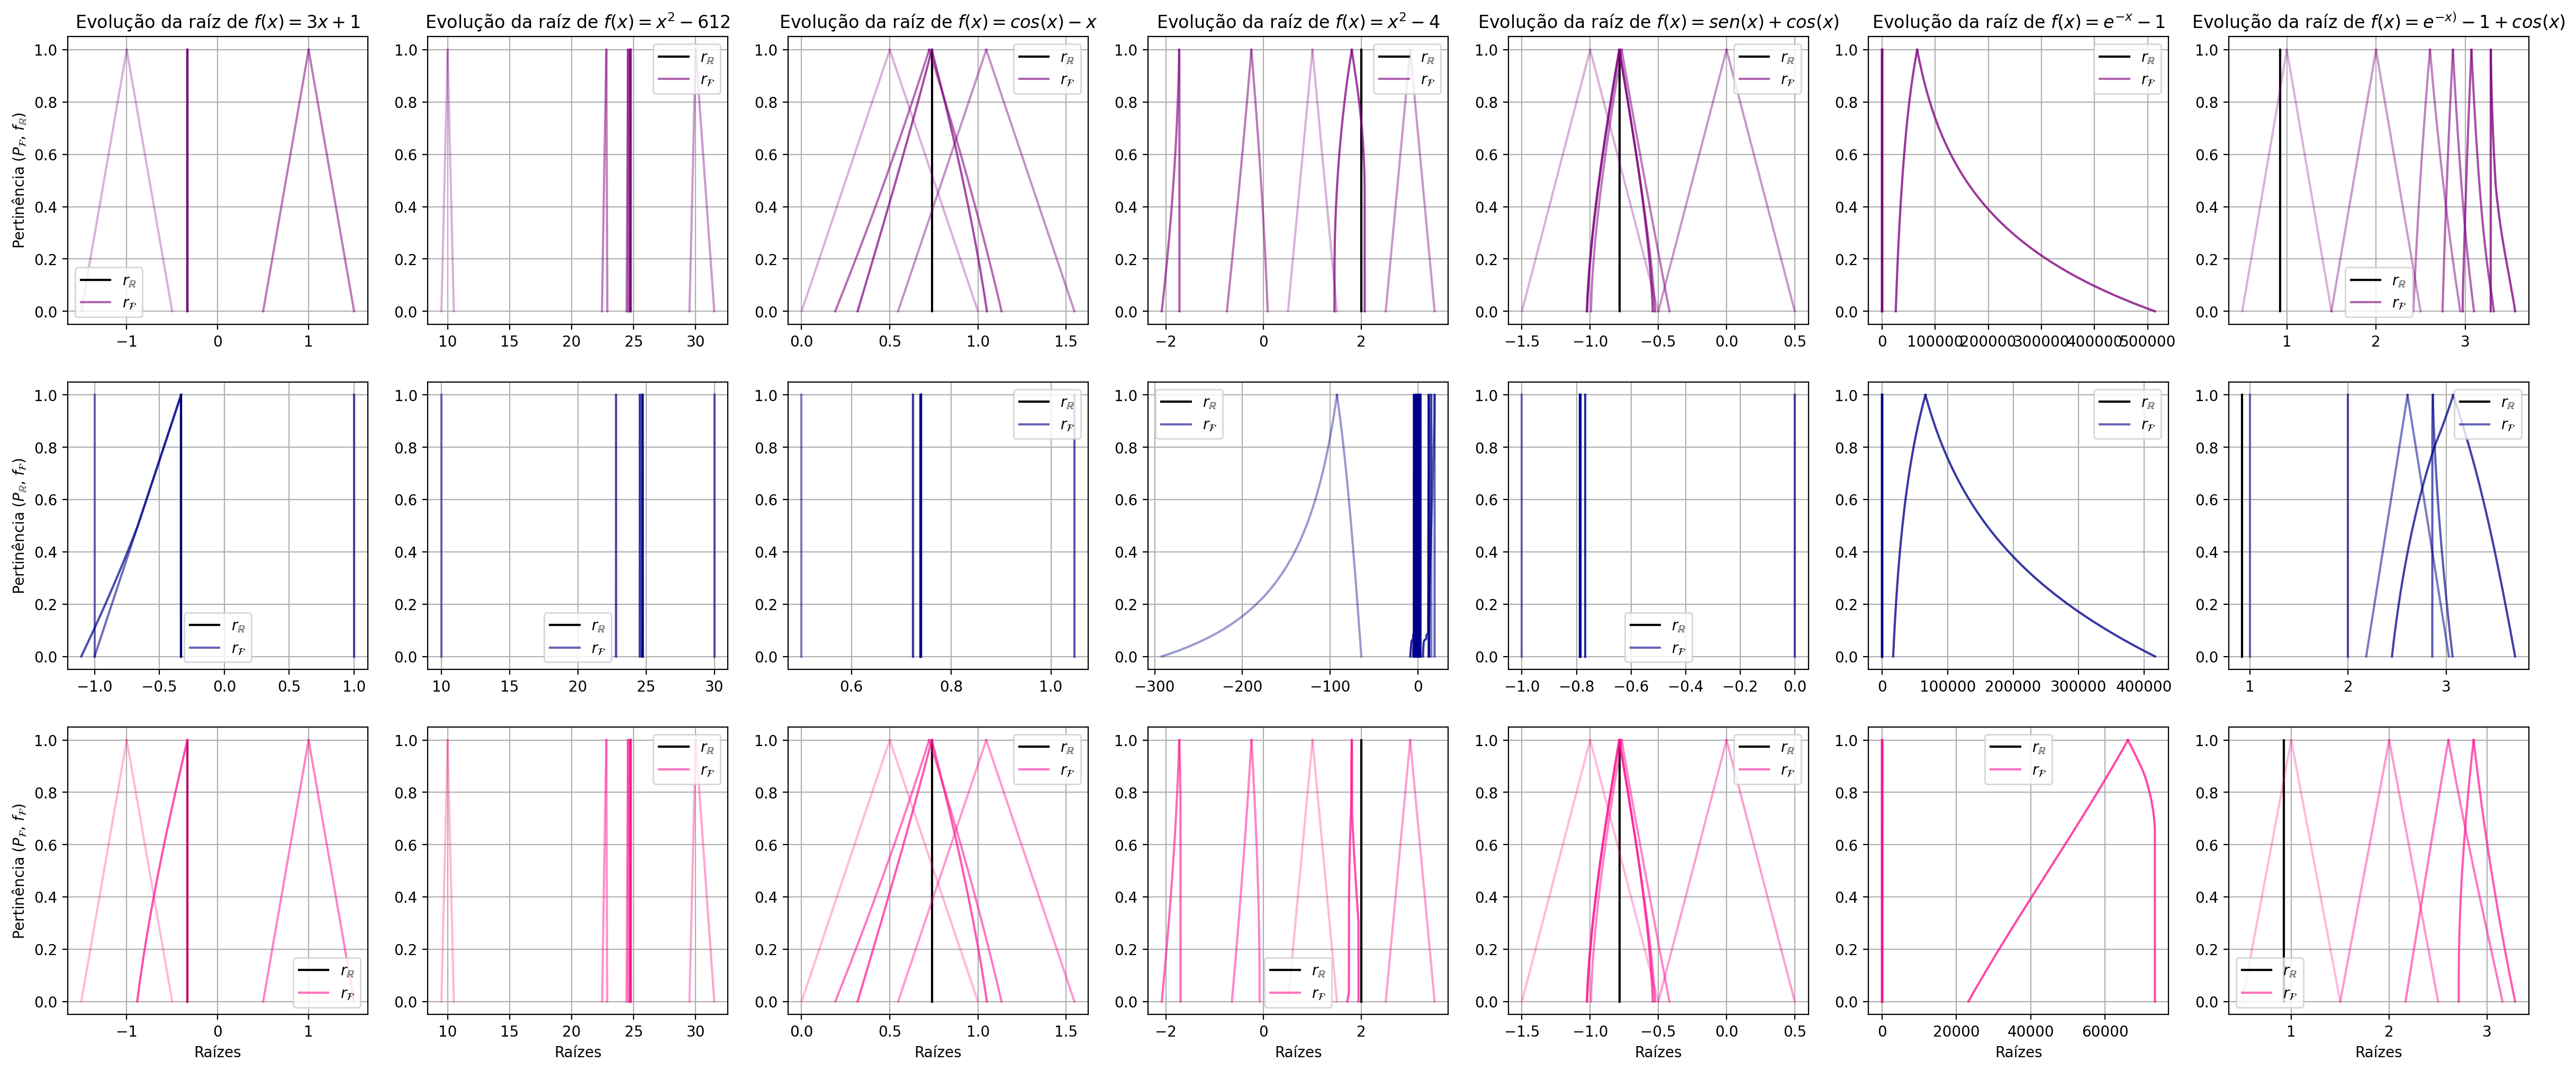

In [46]:
# EVOLUÇÃO DAS RAÍZES

fig, ax = plt.subplots(3,7, dpi= 200, figsize=(30,12))

for i in range(7):
    ax[0][i].set_title(r"Evolução da raíz de "+funcoes[i])
    ax[-1][i].set_xlabel("Raízes")
    for j in range(1,4):
        ax[j-1][0].set_ylabel(f"Pertinência ({metodo[j]})")
        n = len(raizes[i][j])
        ax[j-1][i].plot([raizes[i][0][-1],raizes[i][0][-1]], [0,1], color= "black", label = r"$r_{\mathbb{R}}$")
        ax[j-1][i].plot([], [], color= cor[j], alpha=0.6, label = r"$r_{\mathcal{F}} $")
        for k in range(n):
            x  = raizes[i][j][k]
            if len(x)==2:
                ax[j-1][i].plot(x[0], alphas, color=cor[j], alpha = .3+(k/(1.5*n)))
                ax[j-1][i].plot(x[1], alphas, color=cor[j], alpha = .3+(k/(1.5*n)))
            else:
                k+=1

        ax[j-1][i].legend()
        ax[j-1][i].grid()

    
plt.show()

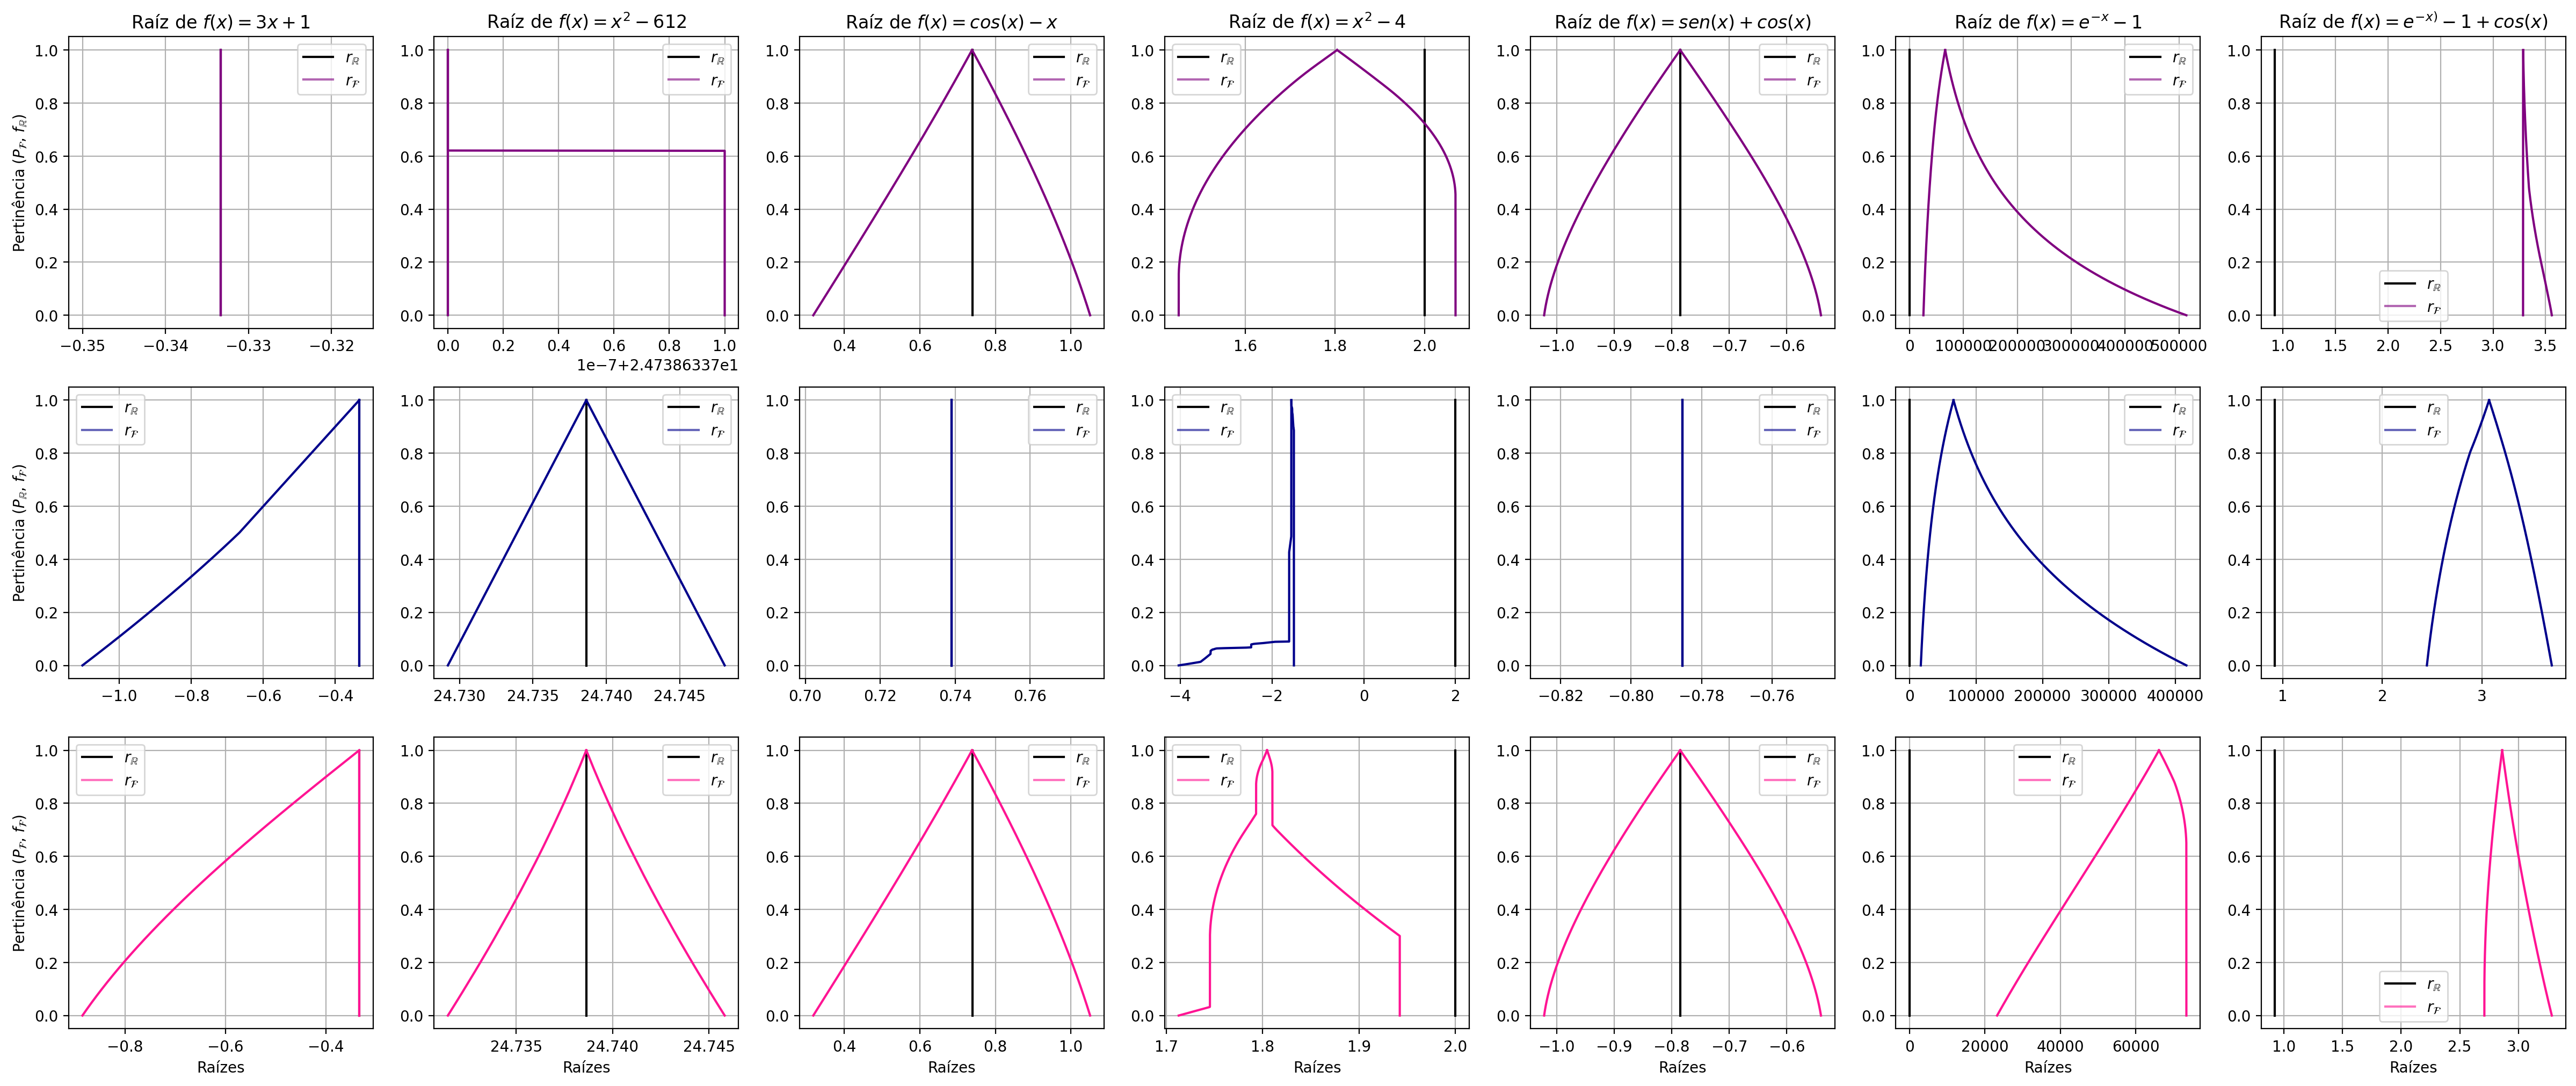

In [43]:
# RAÍZES

fig, ax = plt.subplots(3,7, dpi= 200, figsize=(30,12))

for i in range(7):
    ax[0][i].set_title(r"Raíz de "+funcoes[i])
    ax[-1][i].set_xlabel("Raízes")
    for j in range(1,4):
        ax[j-1][0].set_ylabel(f"Pertinência ({metodo[j]})")
        n = len(raizes[i][j])
        ax[j-1][i].plot([raizes[i][0][-1],raizes[i][0][-1]], [0,1], color= "black", label = r"$r_{\mathbb{R}}$")
        ax[j-1][i].plot([], [], color= cor[j], alpha=0.6, label = r"$r_{\mathcal{F}} $")
        k = -1
        x  = raizes[i][j][k]
        while len(x)==0:
            k-=1
            x = raizes[i][j][k]
            
        ax[j-1][i].plot(x[0], alphas, color=cor[j])
        ax[j-1][i].plot(x[1], alphas, color=cor[j])

        ax[j-1][i].legend()
        ax[j-1][i].grid()

    
plt.show()

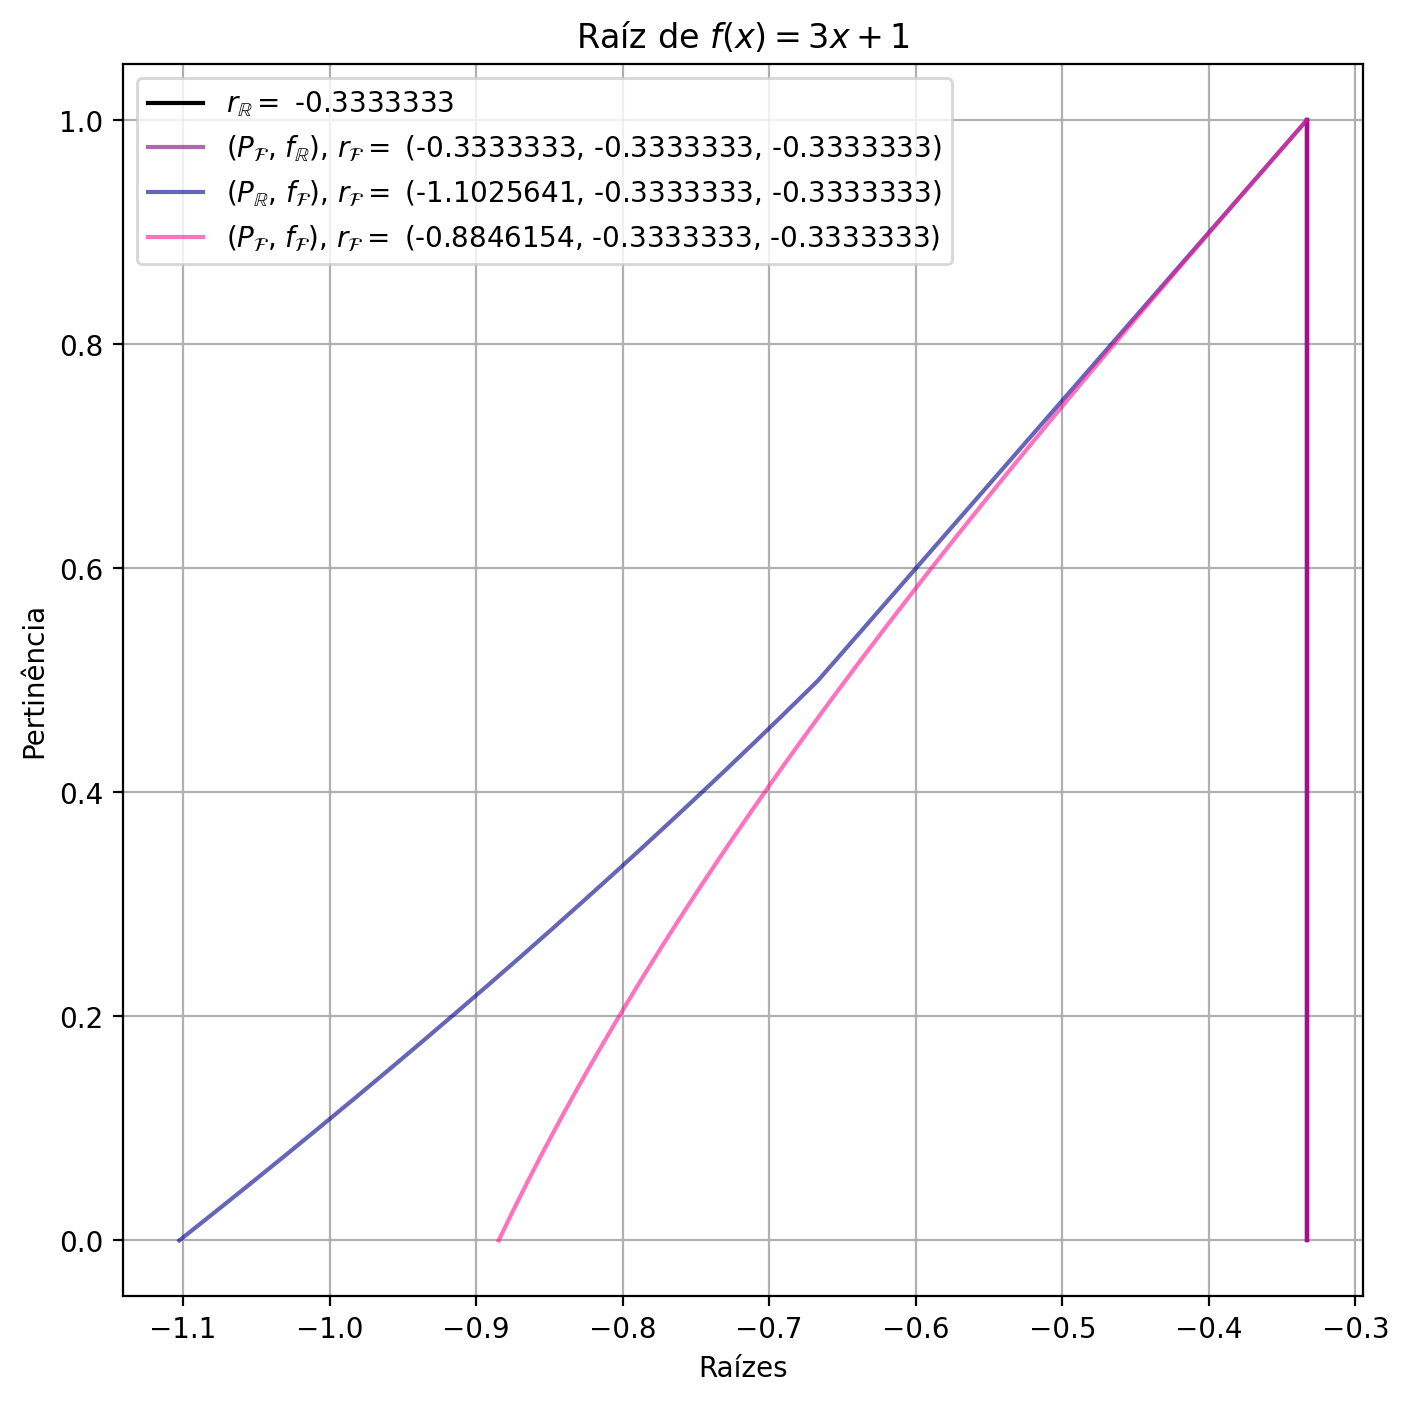

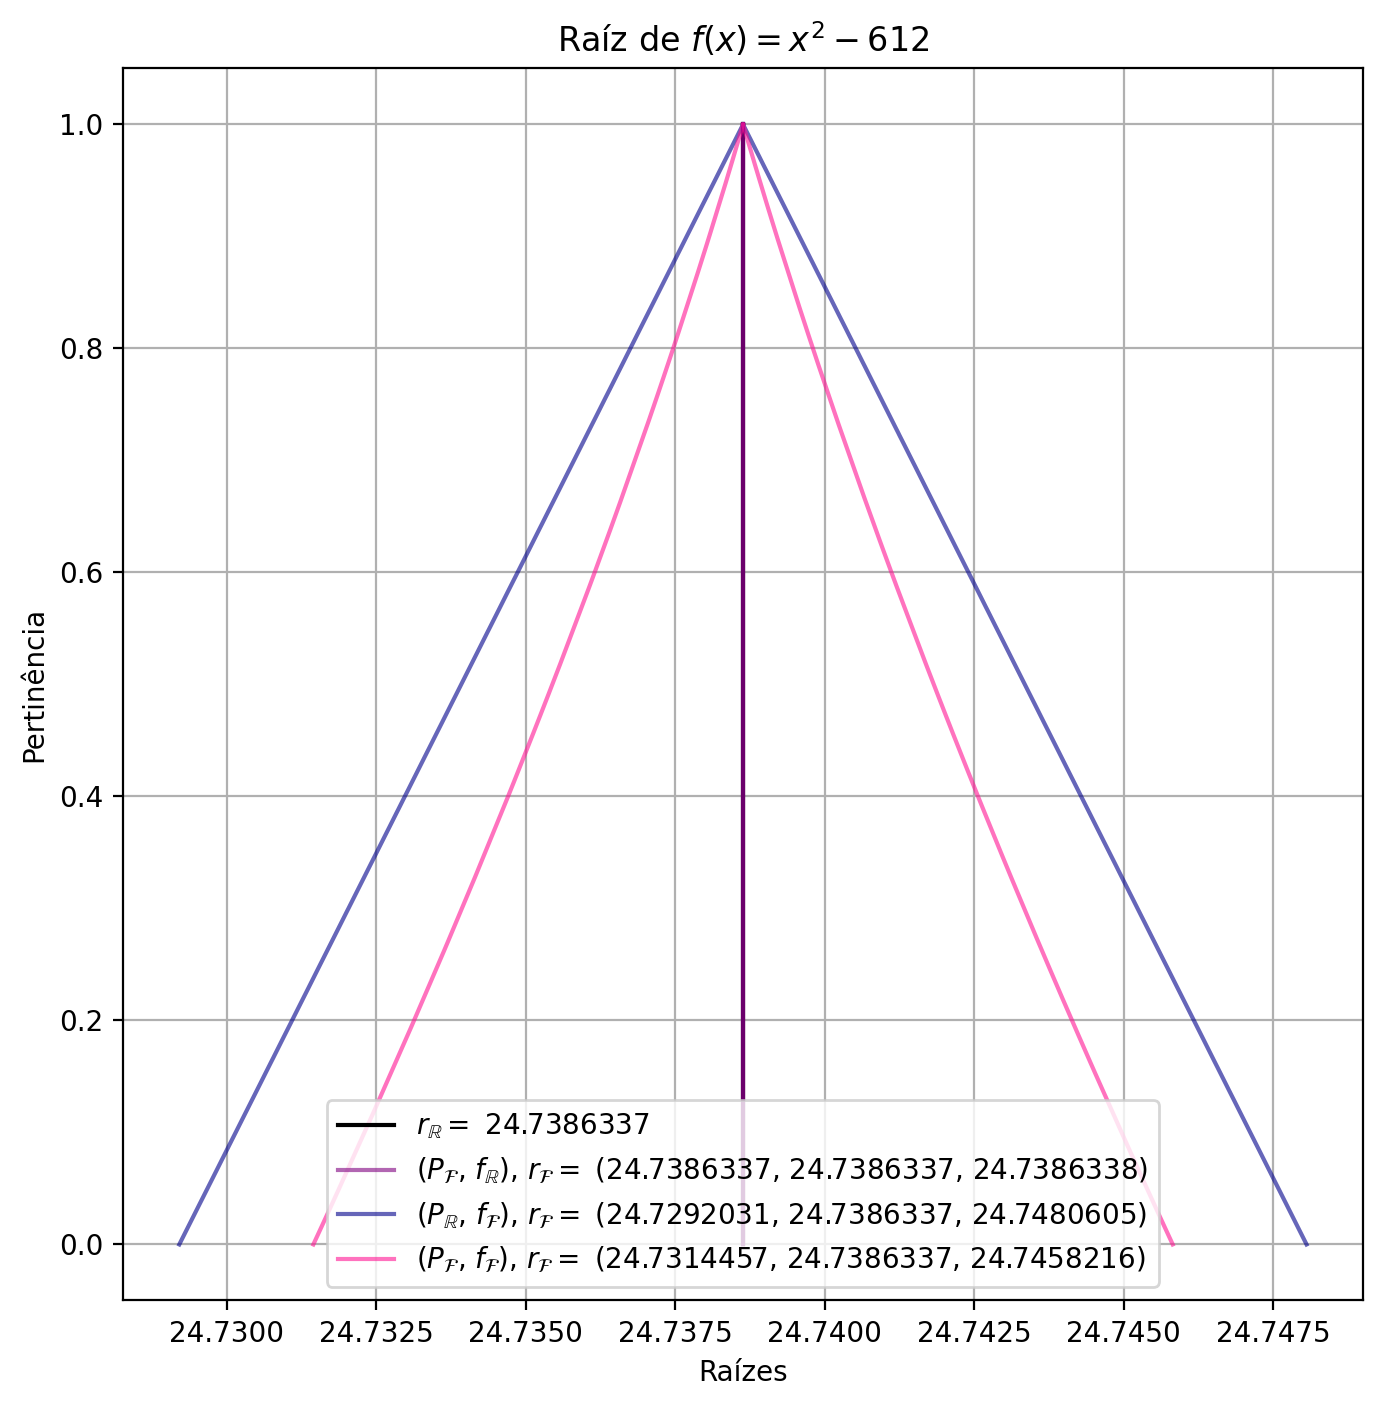

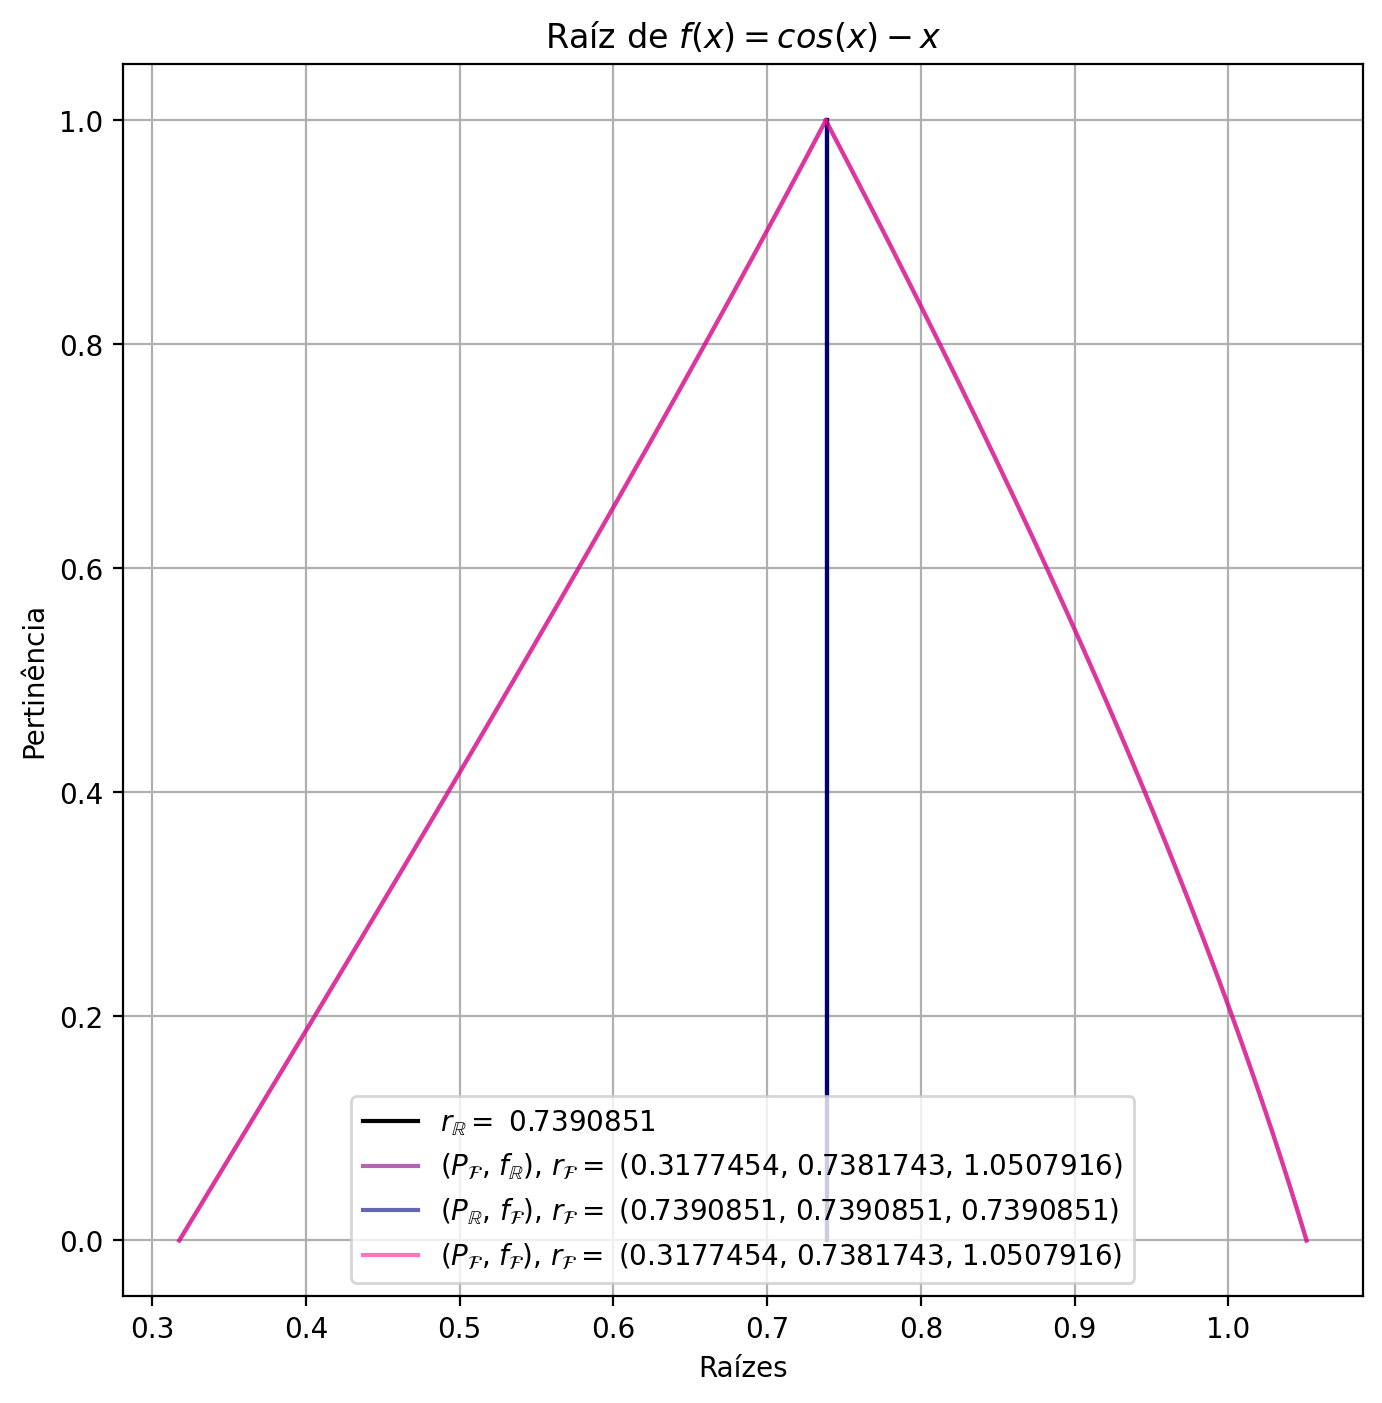

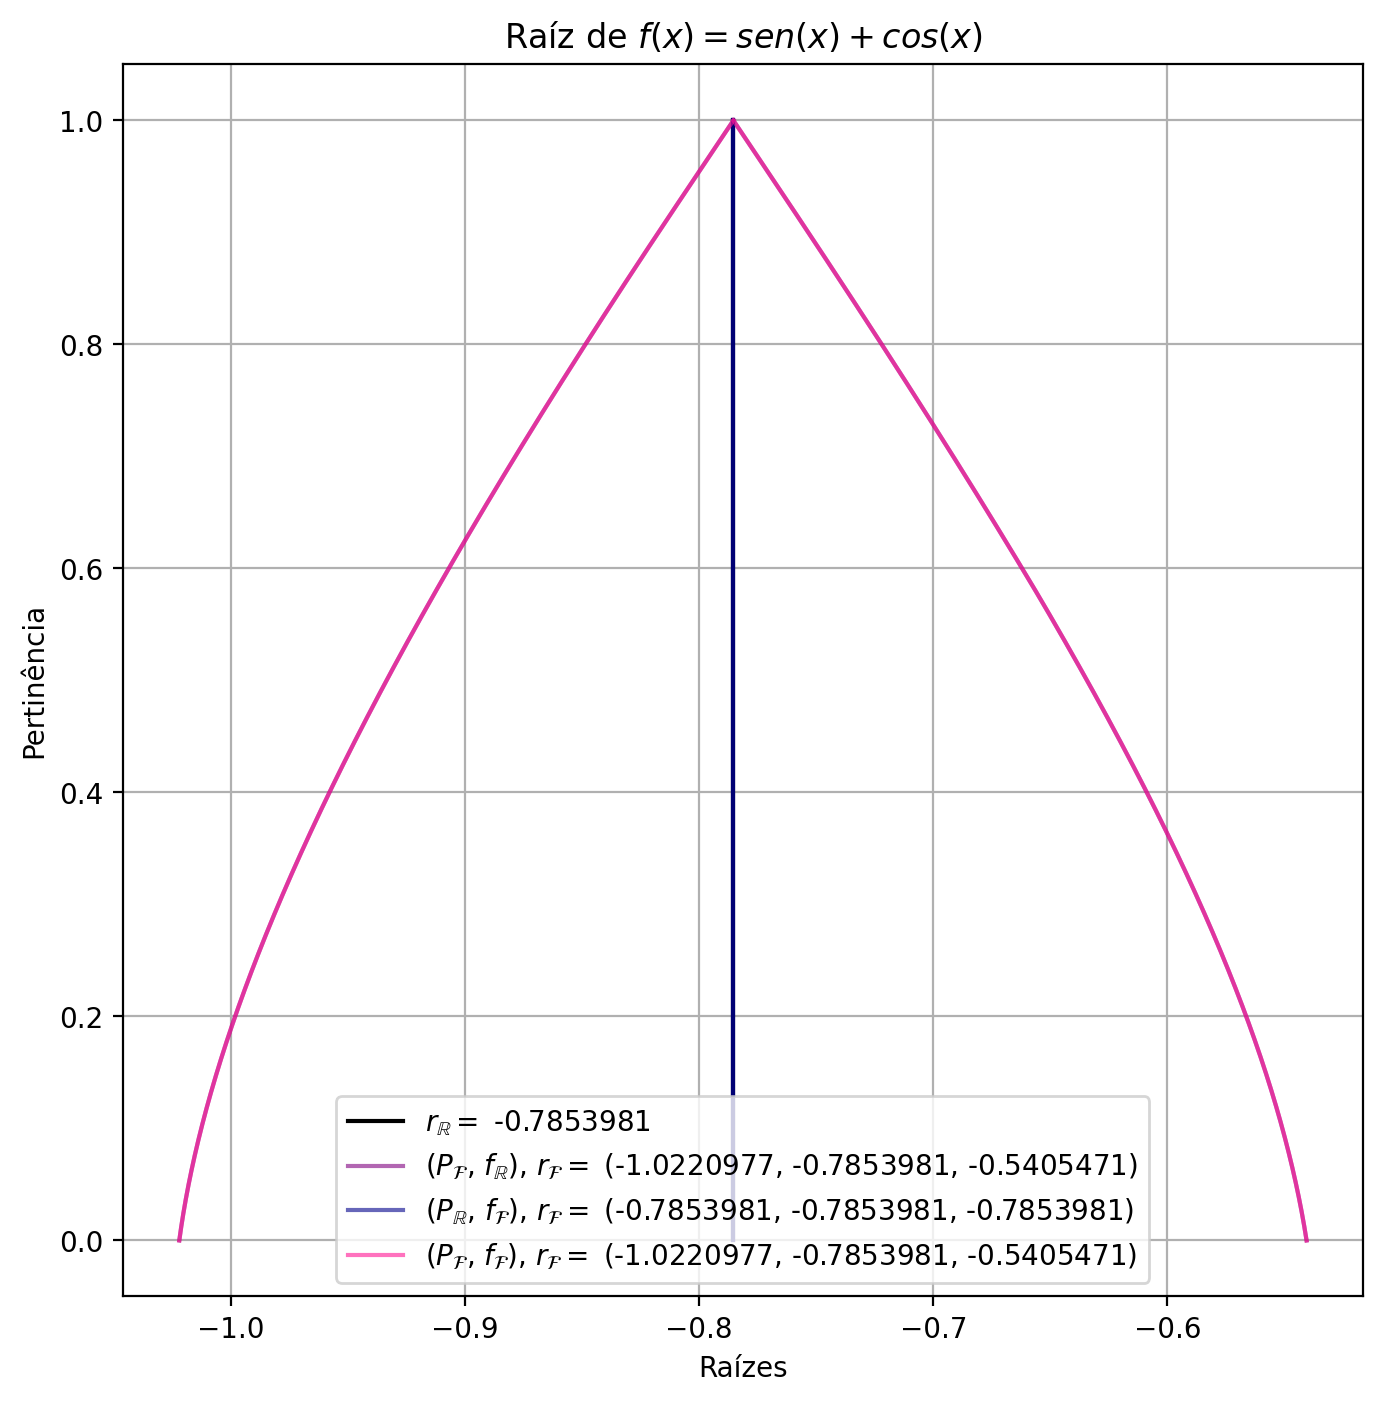

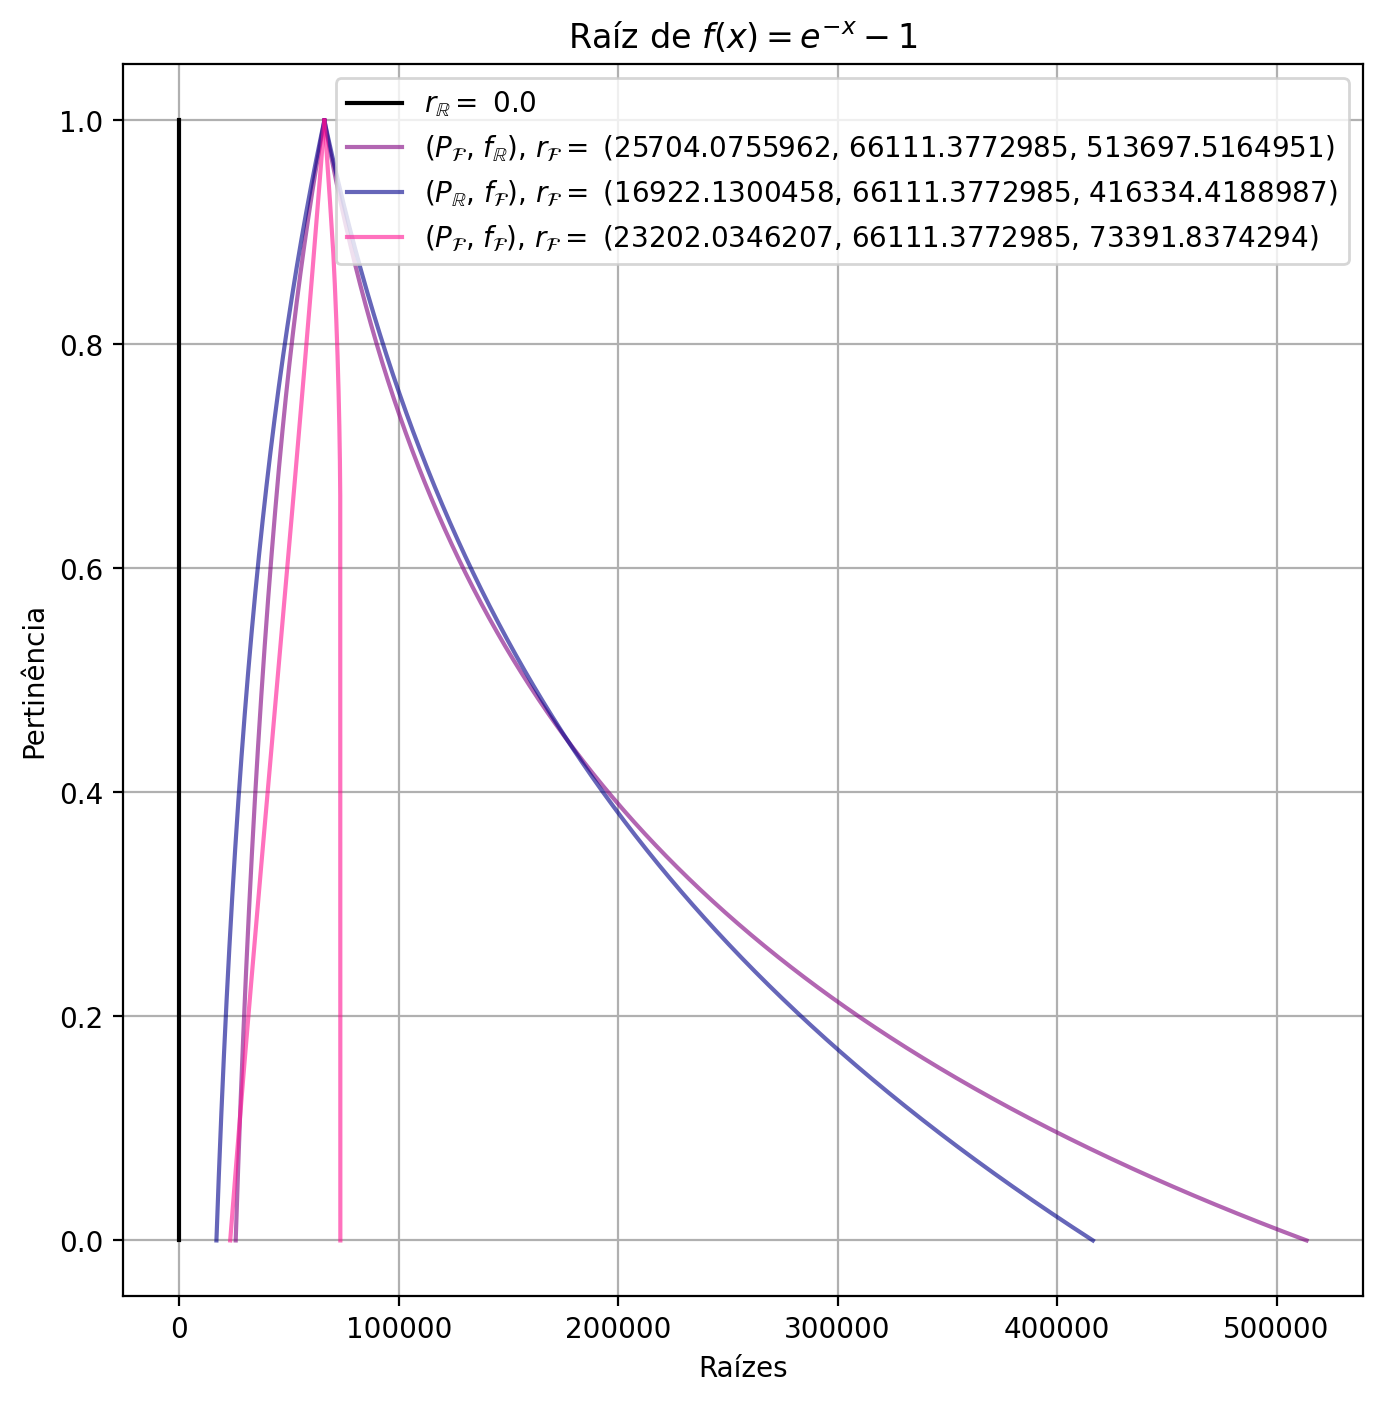

In [45]:
# MELHORES RESULTADOS

best_funcs = [0,1,2,4,5]

for i in best_funcs:
    plt.figure(figsize=(8,8), dpi=200)
    
    plt.plot([raizes[i][0][-1],raizes[i][0][-1]], [0,1], color= "black", label = r"$r_{\mathbb{R}} = $ "+f"{raizes[i][0][-1]}")
        
    for j in range(1,4):
        
        k = -1
        x  = raizes[i][j][k]
        while len(x)==0:
            k-=1
            x = raizes[i][j][k]
            
        plt.plot([], [], color= cor[j], alpha=0.6, label = f"({metodo[j]}), "+r"$r_{\mathcal{F}} = $ "+f"{x[0][0],x[0][-1],x[1][0]}")
        plt.plot(x[0], alphas, color=cor[j], alpha=0.6)
        plt.plot(x[1], alphas, color=cor[j], alpha=0.6)

        plt.legend()
        plt.grid()

    plt.title(r"Raíz de "+funcoes[i])
    plt.xlabel("Raízes")
    plt.ylabel(f"Pertinência")
    plt.show()

Nota-se que na maioria dos casos, os picos das raízes fuzzy coincidem com a raíz crisp pra as três abordagens, com alguns deles encontrando raízes crisp mesmo em funções fuzzy --- o que provavelmente se dá devido ao uso das operações iterativas, que minimizam a incerteza. Mesmo com problemas de divisão por zero, ao resgatar a última raíz calculada pelo método, observamos que os picos, em geral, representam boas aproximações, mas sendo a métrica de Hausdorff uma métrica de máximo, altas incertezas impedem a convergência. 

Os diferentes formatos de números fuzzy se dão pelas consecutivas operações de divisão --- que não garante manutenção do formato dos divisores --- realizadas por diversas iterações, gerando diversas quebras na função de pertinência.

Não é possível definir qual dos três métodos apresentam melhor desempenho, visto que, a cada caso, um deles apresenta menor incerteza. 

## 📌 Conclusões
---

O **método das secantes** utilizando **aritméticas fuzzy interativas** forneceu aproximações para as raízes de diferentes funções nas três abordagens, sendo que, em grande parte das vezes, os **picos das raízes encontradas convergem**, mas apresentam **incerteza alta**. Como **perspectivas**, pretende-se buscar formas de evitar a divisão por zero, e realizar **aplicações** do método à modelos populacionais e a busca de equilíbrio em sistemas elétricos.

## ✨ Agradecimentos
---
Agradecemos pelo apoio financeiro vinculados à FAPESP processos n° 2025/26138-6 e n0 2023/03927-0 e ao CNPq n° 307076/2026-1.

## 📚Referências
---

**[1]** R. L. Burden, J. D. Faires, and A. M. Burden. **Análise numérica**. Cengage Learning, São Paulo, 3 edition, 2016.

**[2]** A. E. R. de Andrade and V. F. Wasques. The interactive fuzzy semigroup (ric,+1/2) and its algebraic structure properties. **Fuzzy Sets and Systems**, 486:108970, 2024.

**[3]** N. J. B. Pinto, V. F. Wasques, W. A. Oliveira, and L. C. Barros. p-fuzzy newton-raphson method. In **Intelligent and Fuzzy Systems**, pages 531–539, Cham, 2024. Springer Nature.

**[4]** L. Stefanini. A generalization of hukuhara difference and division for interval and fuzzy arithmetic. **Fuzzy Sets and Systems**, 161:1564–1584, 2010.